# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  

  Dataset yang digunakan adalah Diabetes Prediction Dataset yang bersumber dari Kaggle
  (https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset).

  Dataset ini berisi 100.000 baris data dengan 9 fitur, yaitu:
  - gender: jenis kelamin pasien
  - age: usia pasien
  - hypertension: riwayat hipertensi (0 = tidak, 1 = ya)
  - heart_disease: riwayat penyakit jantung (0 = tidak, 1 = ya)
  - smoking_history: riwayat merokok
  - bmi: Body Mass Index
  - HbA1c_level: kadar HbA1c dalam darah
  - blood_glucose_level: kadar glukosa darah
  - diabetes: label target (0 = tidak diabetes, 1 = diabetes)

  Tujuan: Memprediksi apakah seseorang menderita diabetes berdasarkan fitur-fitur kesehatan tersebut.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
# Library untuk manipulasi data
import pandas as pd
import numpy as np

# Library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Library untuk preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils import resample

# Library untuk menyimpan hasil preprocessing
import os
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi tampilan plot
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

print("Semua library berhasil diimport!")

Semua library berhasil diimport!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Membaca dataset dari Google Drive
df = pd.read_csv('/content/drive/MyDrive/diabetes_prediction_dataset.csv')

# Menampilkan 5 baris pertama untuk memastikan data berhasil dimuat
print("5 Baris Pertama Dataset:")
print(df.head())

# Menampilkan ukuran dataset (baris x kolom)
print(f"\nUkuran Dataset: {df.shape[0]} baris, {df.shape[1]} kolom")

# Menampilkan nama-nama kolom
print(f"\nNama Kolom: {list(df.columns)}")

# Menampilkan tipe data setiap kolom
print(f"\nTipe Data:")
print(df.dtypes)

5 Baris Pertama Dataset:
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  

Ukuran Dataset: 100000 baris, 9 kolom

Nama Kolom: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

Tipe Data:
gender                  object
age                    float64
hyperte

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [4]:
# Menampilkan informasi umum dataset
# Mencakup jumlah baris, kolom, tipe data, dan jumlah non-null values
print("Informasi Umum Dataset:")
print(df.info())

Informasi Umum Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB
None


In [5]:
# Menampilkan statistik deskriptif dataset
# Mencakup mean, std, min, max, dan quartile untuk kolom numerik
print("Statistik Deskriptif:")
print(df.describe())

Statistik Deskriptif:
                 age  hypertension  heart_disease            bmi  \
count  100000.000000  100000.00000  100000.000000  100000.000000   
mean       41.885856       0.07485       0.039420      27.320767   
std        22.516840       0.26315       0.194593       6.636783   
min         0.080000       0.00000       0.000000      10.010000   
25%        24.000000       0.00000       0.000000      23.630000   
50%        43.000000       0.00000       0.000000      27.320000   
75%        60.000000       0.00000       0.000000      29.580000   
max        80.000000       1.00000       1.000000      95.690000   

         HbA1c_level  blood_glucose_level       diabetes  
count  100000.000000        100000.000000  100000.000000  
mean        5.527507           138.058060       0.085000  
std         1.070672            40.708136       0.278883  
min         3.500000            80.000000       0.000000  
25%         4.800000           100.000000       0.000000  
50%        

In [6]:
# Menampilkan distribusi kelas target (diabetes)
# Untuk mengetahui apakah dataset seimbang atau tidak
print("Distribusi Kelas Target (diabetes):")
print(df['diabetes'].value_counts())
print(f"\nPersentase:")
print(df['diabetes'].value_counts(normalize=True) * 100)

Distribusi Kelas Target (diabetes):
diabetes
0    91500
1     8500
Name: count, dtype: int64

Persentase:
diabetes
0    91.5
1     8.5
Name: proportion, dtype: float64


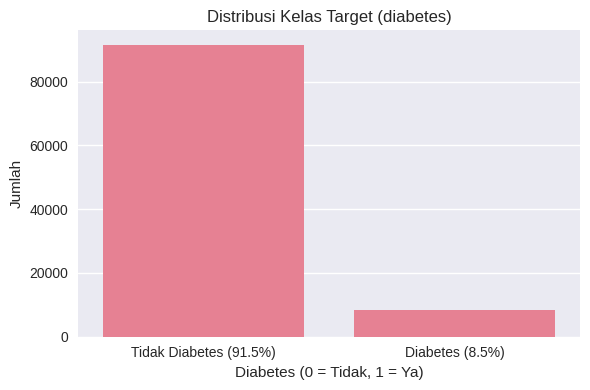

In [7]:
# Visualisasi distribusi kelas target
# Untuk melihat ketidakseimbangan data secara visual
plt.figure(figsize=(6, 4))
sns.countplot(x='diabetes', data=df)
plt.title('Distribusi Kelas Target (diabetes)')
plt.xlabel('Diabetes (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah')
plt.xticks([0, 1], ['Tidak Diabetes (91.5%)', 'Diabetes (8.5%)'])
plt.tight_layout()
plt.show()

In [8]:
# Menampilkan distribusi kolom kategorikal
# Untuk memahami variasi nilai pada kolom gender dan smoking_history
print("Distribusi Gender:")
print(df['gender'].value_counts())

print("\nDistribusi Smoking History:")
print(df['smoking_history'].value_counts())

Distribusi Gender:
gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

Distribusi Smoking History:
smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64


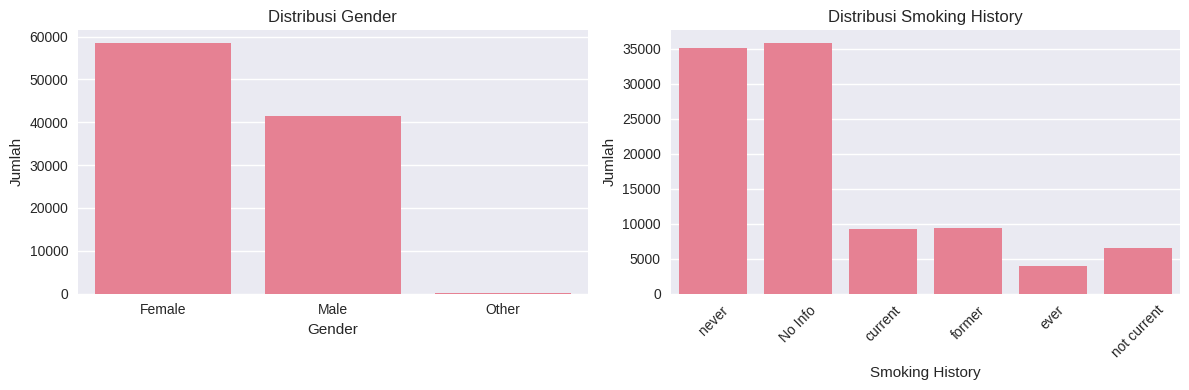

In [9]:
# Visualisasi distribusi kolom kategorikal
# Untuk melihat persebaran nilai gender dan smoking history secara visual
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot distribusi gender
sns.countplot(x='gender', data=df, ax=axes[0])
axes[0].set_title('Distribusi Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Jumlah')

# Plot distribusi smoking history
sns.countplot(x='smoking_history', data=df, ax=axes[1])
axes[1].set_title('Distribusi Smoking History')
axes[1].set_xlabel('Smoking History')
axes[1].set_ylabel('Jumlah')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

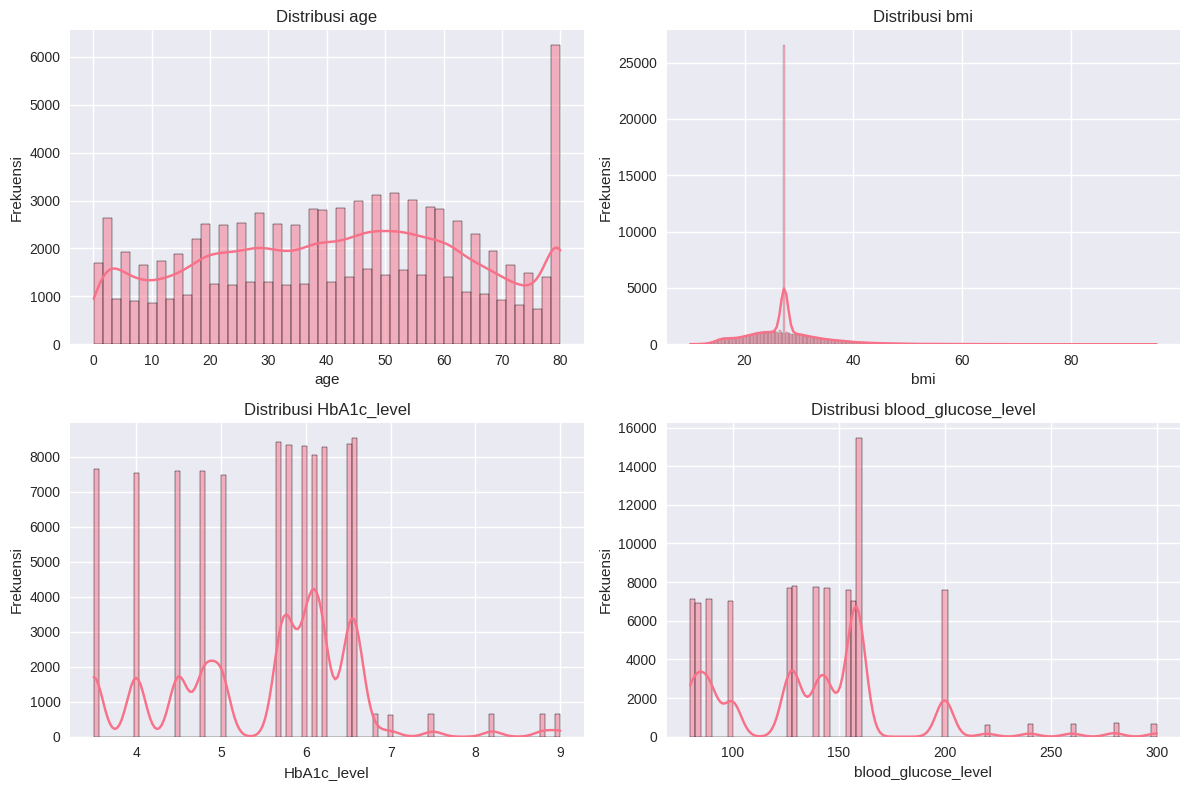

In [10]:
# Visualisasi distribusi kolom numerik
# Untuk melihat persebaran dan bentuk distribusi setiap fitur numerik
numerical_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

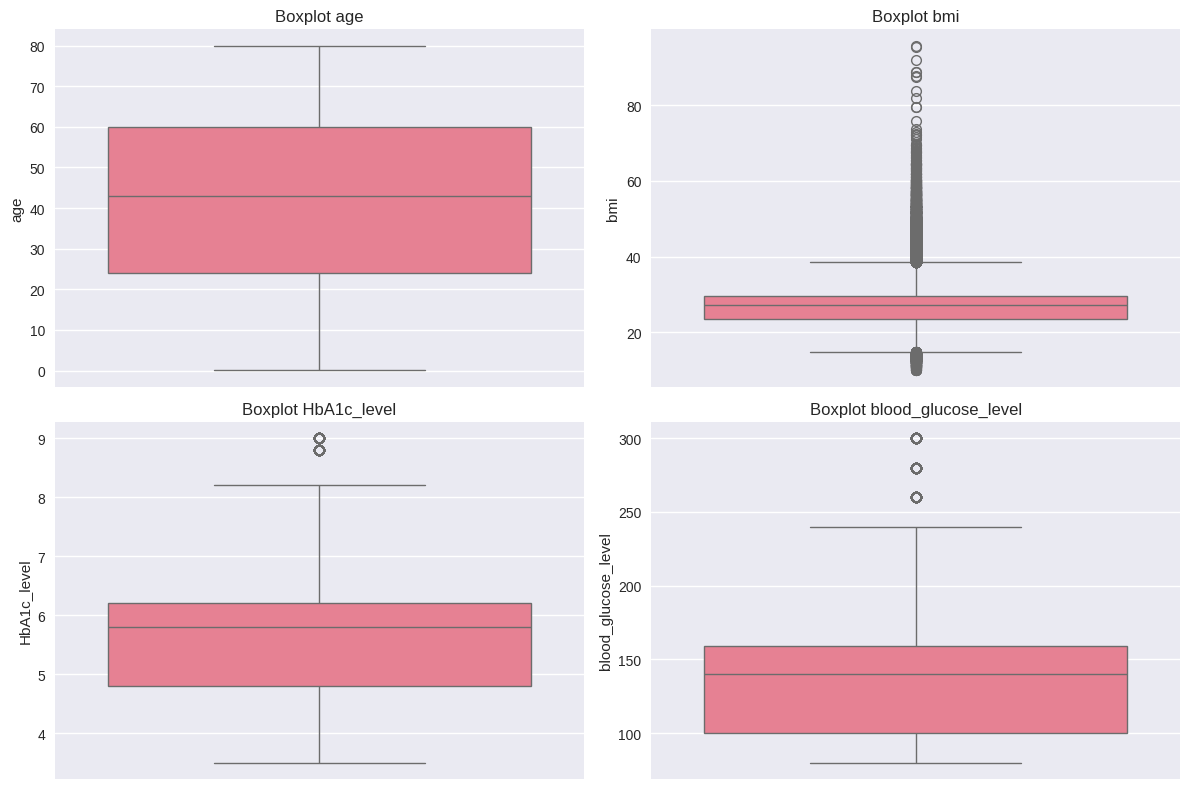

In [11]:
# Visualisasi outlier menggunakan boxplot
# Untuk melihat nilai ekstrem pada setiap fitur numerik
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot {col}')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

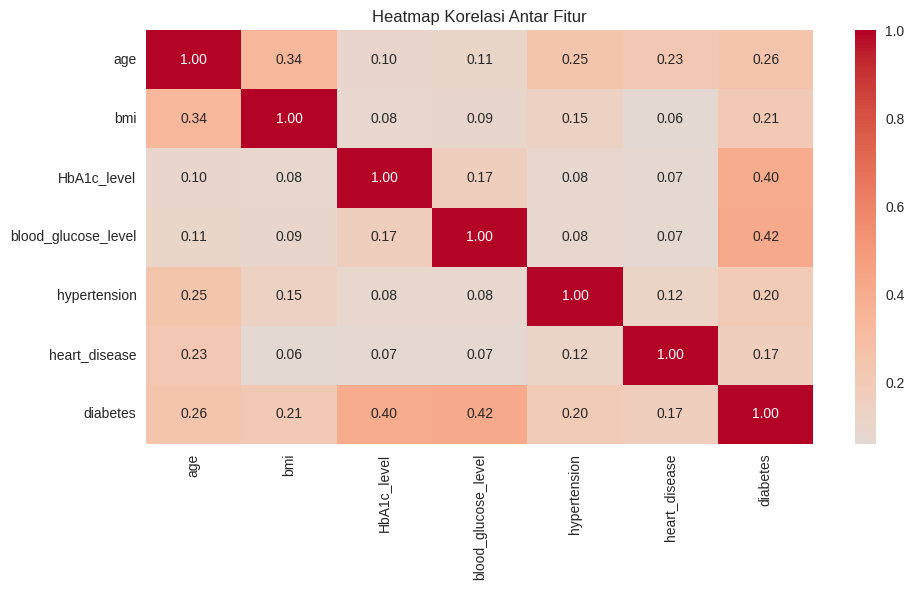

In [12]:
# Visualisasi korelasi antar fitur numerik
# Untuk melihat hubungan antar fitur dan fitur dengan target
plt.figure(figsize=(10, 6))
correlation_matrix = df[['age', 'bmi', 'HbA1c_level',
                          'blood_glucose_level', 'hypertension',
                          'heart_disease', 'diabetes']].corr()

sns.heatmap(correlation_matrix,
            annot=True,       # tampilkan nilai korelasi
            fmt='.2f',        # format 2 desimal
            cmap='coolwarm',  # warna peta
            center=0)         # tengah di 0

plt.title('Heatmap Korelasi Antar Fitur')
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [13]:
# Langkah 1: Cek Missing Values
# Untuk memastikan tidak ada nilai kosong yang dapat mengganggu model
print("Jumlah Missing Values per Kolom:")
print(df.isnull().sum())

print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Jumlah Missing Values per Kolom:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Total missing values: 0


In [14]:
# Langkah 2: Cek dan hapus data duplikat
print(f"Jumlah data duplikat: {df.duplicated().sum()}")

# Hapus duplikat jika ada
df = df.drop_duplicates()
print(f"Ukuran dataset setelah hapus duplikat: {df.shape}")

Jumlah data duplikat: 3854
Ukuran dataset setelah hapus duplikat: (96146, 9)


In [15]:
# Langkah 3: Hapus baris dengan gender 'Other'
# Karena jumlahnya hanya 18 data (sangat sedikit, <0.1% dataset)
df = df[df['gender'] != 'Other']

print(f"Ukuran dataset setelah hapus gender 'Other': {df.shape}")
print(f"\nDistribusi gender setelah pembersihan:")
print(df['gender'].value_counts())

Ukuran dataset setelah hapus gender 'Other': (96128, 9)

Distribusi gender setelah pembersihan:
gender
Female    56161
Male      39967
Name: count, dtype: int64


In [16]:
# Langkah 4: Tangani nilai 'No Info' pada smoking_history
# 'No Info' dianggap sebagai missing value tersamar
# Diganti dengan modus (nilai yang paling sering muncul)
modus_smoking = df[df['smoking_history'] != 'No Info']['smoking_history'].mode()[0]
print(f"Modus smoking_history (tanpa No Info): {modus_smoking}")

df['smoking_history'] = df['smoking_history'].replace('No Info', modus_smoking)

print(f"\nDistribusi smoking_history setelah penanganan:")
print(df['smoking_history'].value_counts())

Modus smoking_history (tanpa No Info): never

Distribusi smoking_history setelah penanganan:
smoking_history
never          67276
former          9299
current         9197
not current     6359
ever            3997
Name: count, dtype: int64


In [17]:
# Langkah 5: Encoding kolom kategorikal
# Mengubah nilai teks menjadi angka agar bisa diproses model

# Encoding gender (Binary: Female=0, Male=1)
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})
print("Encoding gender selesai:")
print(df['gender'].value_counts())

# Encoding smoking_history (Label Encoding)
smoking_mapping = {
    'never': 0,
    'former': 1,
    'ever': 2,
    'not current': 3,
    'current': 4
}
df['smoking_history'] = df['smoking_history'].map(smoking_mapping)
print("\nEncoding smoking_history selesai:")
print(df['smoking_history'].value_counts())

Encoding gender selesai:
gender
0    56161
1    39967
Name: count, dtype: int64

Encoding smoking_history selesai:
smoking_history
0    67276
1     9299
4     9197
3     6359
2     3997
Name: count, dtype: int64


In [18]:
# Langkah 6: Tangani outlier pada kolom BMI menggunakan metode IQR
# Nilai di luar batas bawah dan atas akan di-clip (dipotong)
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1

batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Batas bawah: {batas_bawah}")
print(f"Batas atas: {batas_atas}")

# Clip nilai BMI yang di luar batas
df['bmi'] = df['bmi'].clip(lower=batas_bawah, upper=batas_atas)

print(f"\nNilai BMI setelah clip:")
print(f"Min: {df['bmi'].min()}, Max: {df['bmi'].max()}")

Q1: 23.4, Q3: 29.86, IQR: 6.460000000000001
Batas bawah: 13.709999999999997
Batas atas: 39.55

Nilai BMI setelah clip:
Min: 13.709999999999997, Max: 39.55


In [19]:
# Langkah 7: Split data menjadi fitur (X) dan target (y)
# lalu bagi menjadi data training dan testing
X = df.drop(columns=['diabetes'])  # fitur
y = df['diabetes']                  # target

# Split 80% training, 20% testing
# random_state=42 untuk hasil yang reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Ukuran X_train: {X_train.shape}")
print(f"Ukuran X_test: {X_test.shape}")
print(f"\nDistribusi target di training set:")
print(y_train.value_counts())
print(f"\nDistribusi target di testing set:")
print(y_test.value_counts())

Ukuran X_train: (76902, 8)
Ukuran X_test: (19226, 8)

Distribusi target di training set:
diabetes
0    70116
1     6786
Name: count, dtype: int64

Distribusi target di testing set:
diabetes
0    17530
1     1696
Name: count, dtype: int64


In [20]:
!pip install imbalanced-learn -q

In [21]:
# Langkah 8: Menangani imbalanced data menggunakan SMOTE
# SMOTE hanya diterapkan pada data training, bukan testing
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Ukuran X_train sebelum SMOTE: {X_train.shape}")
print(f"Ukuran X_train setelah SMOTE: {X_train_smote.shape}")
print(f"\nDistribusi target setelah SMOTE:")
print(y_train_smote.value_counts())

Ukuran X_train sebelum SMOTE: (76902, 8)
Ukuran X_train setelah SMOTE: (140232, 8)

Distribusi target setelah SMOTE:
diabetes
0    70116
1    70116
Name: count, dtype: int64


In [22]:
# Langkah 9: Standarisasi fitur numerik menggunakan StandardScaler
# Agar semua fitur berada pada skala yang sama
# Scaler di-fit hanya pada data training, lalu ditransform ke training dan testing

scaler = StandardScaler()

# Fit dan transform data training
X_train_scaled = scaler.fit_transform(X_train_smote)

# Transform data testing (tanpa fit ulang)
X_test_scaled = scaler.transform(X_test)

print("Standarisasi selesai!")
print(f"\nContoh nilai sebelum scaling (X_train_smote):")
print(X_train_smote.iloc[0].values)
print(f"\nContoh nilai setelah scaling (X_train_scaled):")
print(X_train_scaled[0])

Standarisasi selesai!

Contoh nilai sebelum scaling (X_train_smote):
[  0.    22.     0.     0.     0.    24.12   6.1  100.  ]

Contoh nilai setelah scaling (X_train_scaled):
[-0.73453327 -1.32420775 -0.29183663 -0.1997388  -0.56758518 -0.779528
 -0.03140571 -1.11407626]


In [23]:
# Langkah 10: Simpan hasil preprocessing ke file CSV
# Agar bisa digunakan langsung untuk training model

import os

# Buat folder untuk menyimpan hasil preprocessing
os.makedirs('diabetes_preprocessing', exist_ok=True)

# Gabungkan X_train_scaled dan y_train_smote menjadi dataframe
train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
train_scaled_df['diabetes'] = y_train_smote.values

# Gabungkan X_test_scaled dan y_test menjadi dataframe
test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)
test_scaled_df['diabetes'] = y_test.values

# Simpan ke CSV
train_scaled_df.to_csv('diabetes_preprocessing/diabetes_train.csv', index=False)
test_scaled_df.to_csv('diabetes_preprocessing/diabetes_test.csv', index=False)

print("Data preprocessing berhasil disimpan!")
print(f"Training set: {train_scaled_df.shape}")
print(f"Testing set: {test_scaled_df.shape}")

Data preprocessing berhasil disimpan!
Training set: (140232, 9)
Testing set: (19226, 9)


In [24]:
from google.colab import files

files.download('diabetes_preprocessing/diabetes_train.csv')
files.download('diabetes_preprocessing/diabetes_test.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>